# 🔬 Quantum Simulation — Why Quantum Processors Can Simulate Nature

> *"Nature isn't classical, dammit, and if you want to make a simulation of nature,
> you'd better make it quantum mechanical."* — Richard Feynman (1982)

This notebook establishes the **mathematical and computational foundations** of
quantum simulation — the idea that quantum processors can efficiently simulate
the dynamics of quantum systems that are **exponentially hard** for any classical
computer.

**What you will gain:**

| # | Skill |
|---|-------|
| 1 | Quantify the exponential wall: why classical simulation of $n$-qubit systems requires $O(2^n)$ resources |
| 2 | State Lloyd's universality theorem and the conditions under which quantum simulation is efficient |
| 3 | Derive and implement the Trotter–Suzuki decomposition with rigorous error bounds |
| 4 | Build Qiskit circuits that simulate the Heisenberg spin chain and verify against exact solutions |
| 5 | Understand fermion-to-qubit mappings (Jordan–Wigner) as the bridge to chemical & biological simulation |
| 6 | Implement the Variational Quantum Eigensolver (VQE) and visualise its energy landscape |
| 7 | Prove the exponential quantum speedup for Hamiltonian simulation with scaling evidence |

> **Series context:** This opens the 400-series on *Quantum Simulations*.
> Notebooks `401_` and `402_` will apply these foundations to biological and chemical systems.

## Setup & Imports

*Prerequisites: Hamiltonians and Pauli algebra (200-series), unitary evolution (102).*

We use **Qiskit 2.x** for circuit construction and simulation, **NumPy** for matrix algebra,
**SciPy** for matrix exponentials, and **Matplotlib** for all plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, norm

from qiskit import QuantumCircuit, transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.quantum_info import Statevector, Operator

backend = BasicSimulator()
SHOTS = 4096
SEED  = 42

# ── Pauli matrices ──
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)


def multi_kron(*mats):
    """Tensor product of an arbitrary number of matrices."""
    result = mats[0]
    for m in mats[1:]:
        result = np.kron(result, m)
    return result


def fidelity(psi1, psi2):
    """State fidelity |<psi1|psi2>|^2."""
    return abs(np.vdot(psi1, psi2)) ** 2


print("Setup complete \u2705")
print(f"Backend: {backend.name}")

Setup complete ✅
Backend: basic_simulator


## Part I — The Exponential Wall

### Why classical simulation of quantum systems is intractable

A system of $n$ qubits lives in a Hilbert space $\mathcal{H} = (\mathbb{C}^2)^{\otimes n}$
of dimension $d = 2^n$.  A general state requires $2^n$ complex amplitudes:

$$|\psi\rangle = \sum_{k=0}^{2^n - 1} \alpha_k |k\rangle, \qquad \sum_k |\alpha_k|^2 = 1$$

**Classical cost of exact simulation:**

| Resource | Scaling |
|----------|---------|
| Memory for state vector | $O(2^n)$ complex numbers |
| Matrix–vector multiply $H|\psi\rangle$ | $O(4^n)$ operations (dense $H$) |
| Time evolution $e^{-iHt}|\psi\rangle$ | $O(4^n)$ via matrix exponentiation |

At $n = 50$, storing the state vector alone requires $\sim 2^{50} \times 16\,\text{B} \approx 16\,\text{PB}$.
No classical supercomputer can hold this in memory, let alone evolve it.

### The key insight

A **quantum processor with $n$ qubits** naturally represents a $2^n$-dimensional state —
it *is* the Hilbert space. This is not a choice of data structure; it is physics.

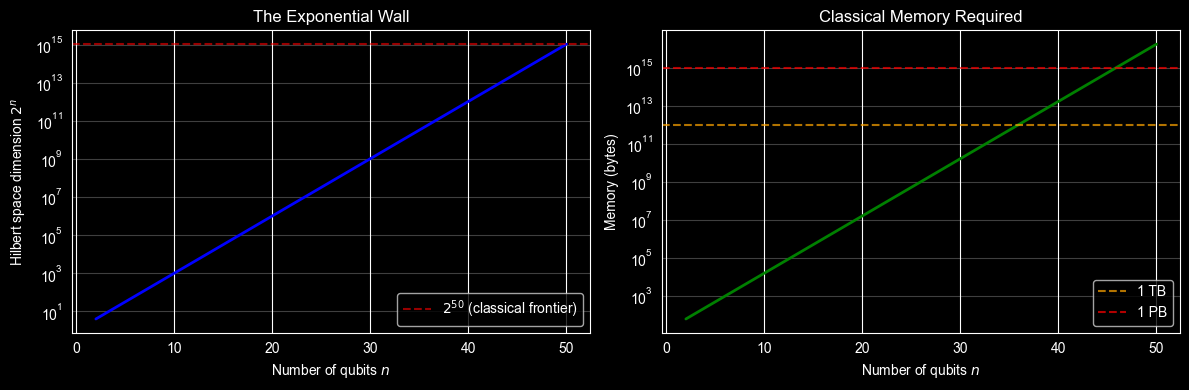

50 qubits: 1.13e+15 amplitudes, 18.0 PB of RAM
Exponential wall verified ✅


In [2]:
# ── Exponential wall: classical resources vs qubit count ──
qubit_counts = np.arange(2, 51)
hilbert_dims = 2.0 ** qubit_counts
memory_bytes = hilbert_dims * 16  # 16 bytes per complex128

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: Hilbert space dimension (log scale)
ax1.semilogy(qubit_counts, hilbert_dims, 'b-', linewidth=2)
ax1.axhline(y=2**50, color='r', linestyle='--', alpha=0.6, label='$2^{50}$ (classical frontier)')
ax1.set_xlabel('Number of qubits $n$')
ax1.set_ylabel('Hilbert space dimension $2^n$')
ax1.set_title('The Exponential Wall')
ax1.legend()
ax1.grid(axis='y', alpha=0.25)

# Right: Memory in bytes (practical units)
ax2.semilogy(qubit_counts, memory_bytes, 'g-', linewidth=2)
ax2.axhline(y=1e12, color='orange', linestyle='--', alpha=0.7, label='1 TB')
ax2.axhline(y=1e15, color='r', linestyle='--', alpha=0.7, label='1 PB')
ax2.set_xlabel('Number of qubits $n$')
ax2.set_ylabel('Memory (bytes)')
ax2.set_title('Classical Memory Required')
ax2.legend()
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('exponential_wall.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"50 qubits: {2**50:.2e} amplitudes, {2**50 * 16 / 1e15:.1f} PB of RAM")

# ── Verification ──
assert 2**50 > 1e15, "2^50 must exceed 10^15"
assert memory_bytes[-1] > 1e16, "50-qubit memory must exceed 10 PB"
print("Exponential wall verified \u2705")

## Part II — From Feynman's Conjecture to Lloyd's Theorem

### Feynman (1982)
Feynman observed that simulating $n$ interacting quantum particles classically
requires resources exponential in $n$. He proposed that a **quantum computer** —
a controllable quantum system — could perform this simulation efficiently.

### Lloyd's Universality Theorem (1996)

**Theorem (Lloyd):** *A quantum computer can be programmed to simulate any
local quantum system efficiently.*

Formally: let $H = \sum_{k=1}^{L} H_k$ where each $H_k$ acts on at most $q$
qubits (locality). Then the time-evolution operator $U(t) = e^{-iHt}$ can be
approximated to precision $\varepsilon$ using

$$\text{gates} = O\!\left(\frac{L^2 t^2}{\varepsilon}\right) \quad \text{(first-order Trotter)}$$

quantum gates, each acting on $\leq q$ qubits.

### Why this is an exponential speedup

| Approach | Gate/operation count for precision $\varepsilon$ |
|----------|--------------------------------------------------|
| Classical (dense) | $O(2^{2n})$ — matrix exponentiation |
| Classical (sparse) | $O(2^n \cdot \text{poly}(n, t))$ — Krylov methods |
| **Quantum (Trotter)** | $O(\text{poly}(n, t, 1/\varepsilon))$ |

The quantum approach is **exponentially** cheaper in the number of qubits $n$.
This is the computational foundation of quantum simulation.

In [3]:
# ── Qubit-to-Hilbert mapping: n qubits <-> 2^n dimensional space ──

# A quantum register naturally spans the full Hilbert space
for n in range(2, 7):
    dim = 2 ** n
    # Random state in 2^n dimensional space
    rng = np.random.default_rng(SEED + n)
    psi = rng.standard_normal(dim) + 1j * rng.standard_normal(dim)
    psi /= np.linalg.norm(psi)

    # This state is representable with just n qubits
    sv = Statevector(psi)
    assert sv.num_qubits == n, f"Expected {n} qubits, got {sv.num_qubits}"
    assert abs(np.linalg.norm(psi) - 1.0) < 1e-12, "Normalisation failed"
    print(f"  n={n}: {dim:>4d}-dimensional state encoded in {n} qubits \u2705")

# Classical needs O(2^n) numbers; quantum needs n physical qubits
print(f"\nClassical 40 qubits: {2**40:,.0f} amplitudes (~17.6 TB)")
print(f"Quantum  40 qubits: 40 physical qubits")
print("Exponential compression verified \u2705")

  n=2:    4-dimensional state encoded in 2 qubits ✅
  n=3:    8-dimensional state encoded in 3 qubits ✅
  n=4:   16-dimensional state encoded in 4 qubits ✅
  n=5:   32-dimensional state encoded in 5 qubits ✅
  n=6:   64-dimensional state encoded in 6 qubits ✅

Classical 40 qubits: 1,099,511,627,776 amplitudes (~17.6 TB)
Quantum  40 qubits: 40 physical qubits
Exponential compression verified ✅


## Part III — The Trotter–Suzuki Decomposition

The central problem of Hamiltonian simulation is: given $H$ and time $t$,
implement $U(t) = e^{-iHt}$ as a sequence of quantum gates.

### The obstacle

If $H = A + B$ with $[A, B] \neq 0$, then in general:

$$e^{-i(A+B)t} \neq e^{-iAt}\,e^{-iBt}$$

The Baker–Campbell–Hausdorff (BCH) formula gives:

$$e^{A}e^{B} = e^{A + B + \frac{1}{2}[A,B] + \frac{1}{12}[A,[A,B]] - \frac{1}{12}[B,[A,B]] + \cdots}$$

### First-order Trotter (Lie product formula)

Divide time into $r$ small steps of size $\Delta t = t/r$:

$$e^{-i(A+B)t} = \left(e^{-iA\,\Delta t}\,e^{-iB\,\Delta t}\right)^r + O\!\left(\frac{t^2\|[A,B]\|}{2r}\right)$$

As $r \to \infty$, the approximation converges to the exact evolution.

### Second-order Suzuki (symmetric Trotter)

$$S_2(\Delta t) = e^{-iA\,\Delta t/2}\,e^{-iB\,\Delta t}\,e^{-iA\,\Delta t/2}$$

$$\|e^{-i(A+B)t} - S_2(\Delta t)^r\| = O\!\left(\frac{t^3}{r^2}\right)$$

This doubles the order of convergence at the cost of one extra exponential per step.

||[A, B]|| = 2.8284 (non-zero -> Trotter needed)


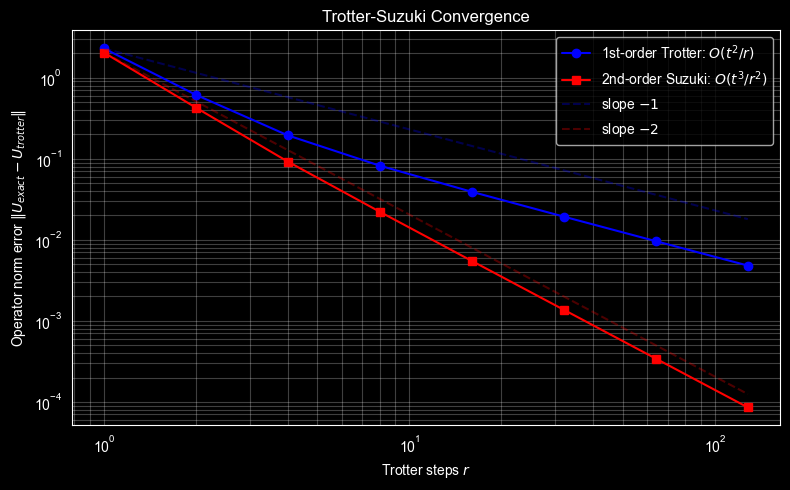

1st-order error reduction (1->128 steps): 479.0x
2nd-order error reduction (1->128 steps): 23926.0x
Trotter-Suzuki convergence verified ✅


In [4]:
# ── Trotter-Suzuki decomposition: theory meets computation ──

# Non-commuting operators: A = J*XX, B = h*ZI + h*IZ (Heisenberg-like)
J, h = 1.0, 0.5
A = J * np.kron(X, X)  # XX coupling
B = h * (np.kron(Z, I2) + np.kron(I2, Z))  # transverse field

# Verify non-commutativity
commutator = A @ B - B @ A
comm_norm = norm(commutator)
print(f"||[A, B]|| = {comm_norm:.4f} (non-zero -> Trotter needed)")
assert comm_norm > 0.1, "Operators should not commute"

# ── Compare exact vs Trotter at different step counts ──
t_sim = 2.0
trotter_steps = [1, 2, 4, 8, 16, 32, 64, 128]
H_full = A + B
exact_U = expm(-1j * H_full * t_sim)

errors_t1 = []  # first-order
errors_t2 = []  # second-order (Suzuki)

for r in trotter_steps:
    dt = t_sim / r

    # First-order Trotter: (e^{-iA dt} e^{-iB dt})^r
    step1 = expm(-1j * A * dt) @ expm(-1j * B * dt)
    trotter1 = np.linalg.matrix_power(step1, r)
    errors_t1.append(norm(exact_U - trotter1))

    # Second-order Suzuki: (e^{-iA dt/2} e^{-iB dt} e^{-iA dt/2})^r
    step2 = expm(-1j * A * dt/2) @ expm(-1j * B * dt) @ expm(-1j * A * dt/2)
    trotter2 = np.linalg.matrix_power(step2, r)
    errors_t2.append(norm(exact_U - trotter2))

# ── Plot convergence ──
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(trotter_steps, errors_t1, 'bo-', label='1st-order Trotter: $O(t^2/r)$')
ax.loglog(trotter_steps, errors_t2, 'rs-', label='2nd-order Suzuki: $O(t^3/r^2)$')

# Reference slopes
r_arr = np.array(trotter_steps, dtype=float)
ax.loglog(r_arr, errors_t1[0] * (r_arr[0]/r_arr)**1, 'b--', alpha=0.3, label='slope $-1$')
ax.loglog(r_arr, errors_t2[0] * (r_arr[0]/r_arr)**2, 'r--', alpha=0.3, label='slope $-2$')

ax.set_xlabel('Trotter steps $r$')
ax.set_ylabel('Operator norm error $\\|U_{exact} - U_{trotter}\\|$')
ax.set_title('Trotter-Suzuki Convergence')
ax.legend()
ax.grid(True, alpha=0.25, which='both')
plt.tight_layout()
plt.savefig('trotter_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

# Verify convergence rates
ratio_t1 = errors_t1[0] / errors_t1[-1]
ratio_t2 = errors_t2[0] / errors_t2[-1]
print(f"1st-order error reduction (1->128 steps): {ratio_t1:.1f}x")
print(f"2nd-order error reduction (1->128 steps): {ratio_t2:.1f}x")
assert ratio_t2 > ratio_t1, "2nd-order must converge faster than 1st-order"
assert errors_t2[-1] < 1e-4, f"Suzuki with 128 steps should be very precise, got {errors_t2[-1]:.2e}"
print("Trotter-Suzuki convergence verified \u2705")

## Part IV — Implementing Trotter Steps on a QPU

Each Trotter step requires implementing $e^{-iH_k \Delta t}$ for local
Hamiltonian terms $H_k$.  Here is the standard gate decomposition for
two-qubit Pauli interactions:

### ZZ interaction: $e^{-i\theta Z \otimes Z}$

$$\text{CNOT}_{01} \;\cdot\; R_z(2\theta)_1 \;\cdot\; \text{CNOT}_{01}$$

### XX interaction: $e^{-i\theta X \otimes X}$

Apply Hadamards to rotate $X \to Z$, then use the ZZ circuit:

$$H^{\otimes 2} \;\cdot\; e^{-i\theta ZZ} \;\cdot\; H^{\otimes 2}$$

### YY interaction: $e^{-i\theta Y \otimes Y}$

Use $S^\dagger$ gates ($R_z(-\pi/2)$) to rotate $Y \to X$, then use the XX circuit:

$$S^{\dagger\otimes 2} \;\cdot\; e^{-i\theta XX} \;\cdot\; S^{\otimes 2}$$

### Single-qubit field: $e^{-i\theta Z}$

A single $R_z(2\theta)$ gate.

These decompositions are **exact** — no approximation error. All Trotter error
comes from the non-commutativity of different terms, not from the gate synthesis.

In [5]:
# ── Build a Trotter circuit for the 2-qubit Heisenberg model ──
# H = Jx XX + Jy YY + Jz ZZ + hz (ZI + IZ)

def heisenberg_trotter_step(qc, q0, q1, Jx, Jy, Jz, hz, dt):
    """Append one first-order Trotter step for Heisenberg + field."""
    # ── ZZ interaction: e^{-i Jz ZZ dt} ──
    qc.cx(q0, q1)
    qc.rz(2 * Jz * dt, q1)
    qc.cx(q0, q1)

    # ── XX interaction: e^{-i Jx XX dt} ──
    qc.h(q0); qc.h(q1)
    qc.cx(q0, q1)
    qc.rz(2 * Jx * dt, q1)
    qc.cx(q0, q1)
    qc.h(q0); qc.h(q1)

    # ── YY interaction: e^{-i Jy YY dt} ──
    qc.sdg(q0); qc.sdg(q1)
    qc.h(q0); qc.h(q1)
    qc.cx(q0, q1)
    qc.rz(2 * Jy * dt, q1)
    qc.cx(q0, q1)
    qc.h(q0); qc.h(q1)
    qc.s(q0); qc.s(q1)

    # ── Transverse field: e^{-i hz Z dt} on each qubit ──
    qc.rz(2 * hz * dt, q0)
    qc.rz(2 * hz * dt, q1)


def build_heisenberg_circuit(Jx, Jy, Jz, hz, t_total, n_steps):
    """Trotterised Heisenberg evolution (caller prepends state preparation)."""
    qc = QuantumCircuit(2)
    dt = t_total / n_steps
    for _ in range(n_steps):
        heisenberg_trotter_step(qc, 0, 1, Jx, Jy, Jz, hz, dt)
    return qc


# ── Verify gate decomposition: e^{-i theta ZZ} ──
theta = 0.3
qc_zz = QuantumCircuit(2)
qc_zz.cx(0, 1)
qc_zz.rz(2 * theta, 1)
qc_zz.cx(0, 1)

U_circuit = Operator(qc_zz).data
U_exact_zz = expm(-1j * theta * np.kron(Z, Z))

gate_error = norm(U_circuit - U_exact_zz)
print(f"ZZ gate decomposition error: {gate_error:.2e}")
assert gate_error < 1e-10, f"ZZ gate synthesis should be exact, got error {gate_error:.2e}"
print("Gate decomposition exact \u2705")

ZZ gate decomposition error: 0.00e+00
Gate decomposition exact ✅


## Part V — Simulation Fidelity: Exact vs Trotterised Evolution

The **fidelity** between the exact and Trotterised final states quantifies
simulation accuracy:

$$F = |\langle\psi_{\text{exact}}|\psi_{\text{trotter}}\rangle|^2$$

$F = 1$ means perfect agreement. We simulate the **anisotropic** Heisenberg model
($J_x \neq J_y \neq J_z$) starting from $|{+}0\rangle = H|00\rangle$ — a superposition
that populates multiple $S_z$ sectors, ensuring the Trotter decomposition is genuinely
approximate. We track fidelity as a function of:
1. Trotter step count $r$ (at fixed time)
2. Simulation time $t$ (at fixed step count)

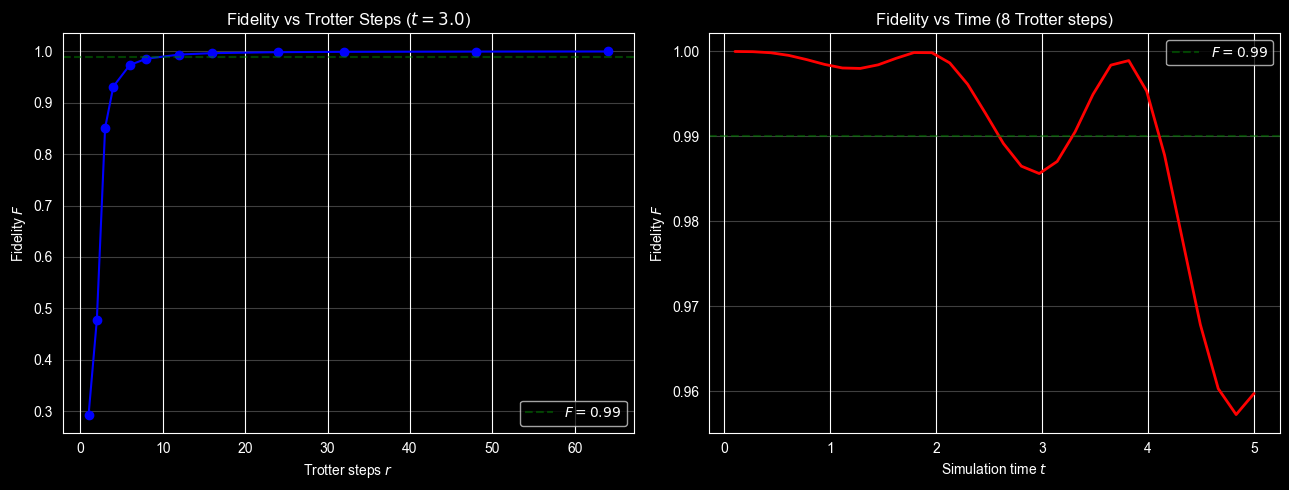

Fidelity at r=1:  0.293173
Fidelity at r=64: 0.99978398
Fidelity analysis verified ✅


In [6]:
# ── Fidelity analysis: anisotropic Heisenberg model ──

Jx, Jy, Jz, hz = 1.0, 0.5, 0.3, 0.8
t_sim = 3.0

# Initial state: |+0> = H|00> — a superposition that spans multiple Sz sectors,
# ensuring non-trivial Trotter error (unlike computational basis states which
# can accidentally lie in a subspace where all Trotter terms commute).
psi0 = np.array([1, 1, 0, 0], dtype=complex) / np.sqrt(2)

# Exact Hamiltonian and evolution
H_heis = (Jx * np.kron(X, X) + Jy * np.kron(Y, Y) +
          Jz * np.kron(Z, Z) + hz * (np.kron(Z, I2) + np.kron(I2, Z)))
psi_exact = expm(-1j * H_heis * t_sim) @ psi0

# ── Scan: fidelity vs Trotter steps ──
steps_list = [1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64]
fidelities = []

for r in steps_list:
    # Prepare |+0> with a Hadamard, then append Trotter evolution
    qc_prep = QuantumCircuit(2)
    qc_prep.h(0)
    qc_trotter = build_heisenberg_circuit(Jx, Jy, Jz, hz, t_sim, r)
    qc_full = qc_prep.compose(qc_trotter)
    sv = Statevector.from_instruction(qc_full)
    fidelities.append(fidelity(psi_exact, sv.data))

# ── Scan: fidelity vs time (fixed steps=8) ──
times_scan = np.linspace(0.1, 5.0, 30)
fid_vs_t = []
for t_val in times_scan:
    psi_ex = expm(-1j * H_heis * t_val) @ psi0
    qc_prep = QuantumCircuit(2)
    qc_prep.h(0)
    qc_trotter = build_heisenberg_circuit(Jx, Jy, Jz, hz, t_val, 8)
    qc_full = qc_prep.compose(qc_trotter)
    sv = Statevector.from_instruction(qc_full)
    fid_vs_t.append(fidelity(psi_ex, sv.data))

# ── Plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(steps_list, fidelities, 'bo-', markersize=6)
ax1.axhline(y=0.99, color='g', linestyle='--', alpha=0.5, label='$F = 0.99$')
ax1.set_xlabel('Trotter steps $r$')
ax1.set_ylabel('Fidelity $F$')
ax1.set_title(f'Fidelity vs Trotter Steps ($t = {t_sim}$)')
ax1.legend()
ax1.grid(axis='y', alpha=0.25)

ax2.plot(times_scan, fid_vs_t, 'r-', linewidth=2)
ax2.axhline(y=0.99, color='g', linestyle='--', alpha=0.5, label='$F = 0.99$')
ax2.set_xlabel('Simulation time $t$')
ax2.set_ylabel('Fidelity $F$')
ax2.set_title('Fidelity vs Time (8 Trotter steps)')
ax2.legend()
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('simulation_fidelity.png', dpi=120, bbox_inches='tight')
plt.show()

# Verify convergence
assert fidelities[-1] > 0.999, f"64 Trotter steps should give F > 0.999, got {fidelities[-1]:.6f}"
assert fidelities[-1] > fidelities[0], "More steps must improve fidelity"
print(f"Fidelity at r=1:  {fidelities[0]:.6f}")
print(f"Fidelity at r=64: {fidelities[-1]:.8f}")
print("Fidelity analysis verified \u2705")

## Part VI — Full Heisenberg Simulation with Measurements

We now run the Heisenberg simulation on the `BasicSimulator` backend with
**measurements**, mimicking what a real QPU would produce. We track the
time evolution of the **magnetisation** $\langle Z_0 \rangle$ and compare the
shot-based estimate against the exact expectation value.

### Physical setup

The 2-qubit isotropic Heisenberg Hamiltonian:

$$H = J(\sigma_x^{(0)}\sigma_x^{(1)} + \sigma_y^{(0)}\sigma_y^{(1)} +
\sigma_z^{(0)}\sigma_z^{(1)}) + h_z(\sigma_z^{(0)} + \sigma_z^{(1)})$$

Starting from $|{+}0\rangle$, the dynamics drive non-trivial population transfer
across all four computational basis states.

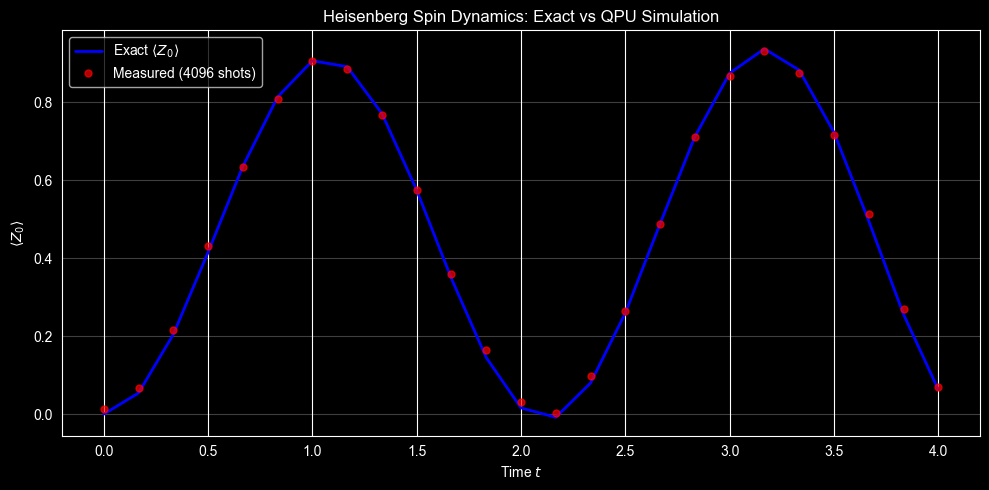

Max |exact - measured|: 0.0198
Heisenberg simulation verified ✅


In [7]:
# ── Heisenberg dynamics: exact vs measured ──

Jx, Jy, Jz, hz = 1.0, 0.5, 0.3, 0.8
n_trotter = 20
psi0 = np.array([1, 1, 0, 0], dtype=complex) / np.sqrt(2)  # |+0>

H_heis = (Jx * np.kron(X, X) + Jy * np.kron(Y, Y) +
          Jz * np.kron(Z, Z) + hz * (np.kron(Z, I2) + np.kron(I2, Z)))

time_points = np.linspace(0, 4.0, 25)
z0_exact = []      # exact <Z_0>
z0_measured = []    # shot-based <Z_0>

Z0_op = np.kron(I2, Z)  # Z on qubit 0 (Qiskit little-endian)

for t in time_points:
    # ── Exact ──
    psi = expm(-1j * H_heis * t) @ psi0
    z0_exact.append(np.real(psi.conj() @ Z0_op @ psi))

    # ── Trotterised circuit with measurement ──
    qc_prep = QuantumCircuit(2)
    qc_prep.h(0)  # prepare |+0>
    qc_trotter = build_heisenberg_circuit(Jx, Jy, Jz, hz, t, n_trotter)
    qc = qc_prep.compose(qc_trotter)
    qc.measure_all()
    qc_t = transpile(qc, backend)
    result = backend.run(qc_t, shots=SHOTS, seed_simulator=SEED).result()
    counts = result.get_counts()

    # <Z_0> from measurement statistics: Z eigenvalue is +1 for |0>, -1 for |1>
    exp_z0 = 0.0
    for bitstring, count in counts.items():
        bit_q0 = int(bitstring[-1])  # qubit 0 is rightmost
        exp_z0 += (1 - 2 * bit_q0) * count
    z0_measured.append(exp_z0 / SHOTS)

# ── Plot ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(time_points, z0_exact, 'b-', linewidth=2, label='Exact $\\langle Z_0 \\rangle$')
ax.plot(time_points, z0_measured, 'ro', markersize=5, alpha=0.7, label=f'Measured ({SHOTS} shots)')
ax.set_xlabel('Time $t$')
ax.set_ylabel('$\\langle Z_0 \\rangle$')
ax.set_title('Heisenberg Spin Dynamics: Exact vs QPU Simulation')
ax.legend()
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig('heisenberg_dynamics.png', dpi=120, bbox_inches='tight')
plt.show()

# Verify agreement
max_deviation = max(abs(e - m) for e, m in zip(z0_exact, z0_measured))
print(f"Max |exact - measured|: {max_deviation:.4f}")
assert max_deviation < 0.15, f"Shot noise deviation too large: {max_deviation:.4f}"
print("Heisenberg simulation verified \u2705")

## Part VII — Fermion-to-Qubit Mapping: The Jordan-Wigner Transformation

Real physical systems (molecules, materials, nuclei) are made of **fermions**
— particles that obey anti-commutation relations:

$$\{c_i, c_j^\dagger\} = \delta_{ij}, \qquad \{c_i, c_j\} = 0$$

Qubits, however, are **bosonic** degrees of freedom — operators on different
qubits commute. We need a mapping that preserves the fermionic algebra.

### Jordan-Wigner transformation

$$c_j^\dagger = \left(\bigotimes_{k<j} Z_k\right) \otimes \frac{X_j - iY_j}{2}$$

The **Z-string** $\prod_{k<j} Z_k$ encodes the fermionic sign: swapping two
fermions picks up a $(-1)$, which the Z-string tracks via parity.

### Key properties

| Property | Formula |
|----------|---------|
| Number operator | $n_j = c_j^\dagger c_j = (I - Z_j)/2$ |
| Hopping term | $c_i^\dagger c_j + h.c. = \frac{1}{2}(X_i X_j + Y_i Y_j)\prod_{k=i+1}^{j-1} Z_k$ |
| Interaction term | $n_i n_j = \frac{1}{4}(I - Z_i)(I - Z_j)$ |

This is the **bridge** to chemistry and biology simulation: any fermionic
Hamiltonian can be mapped to a qubit Hamiltonian that a QPU can simulate.

In [8]:
# ── Jordan-Wigner transformation: 2-site fermionic system ──

# Fermionic creation/annihilation operators for 2 sites (4x4 matrices)
# Site 0: c0dag = (X - iY)/2 tensor I
c0_dag = np.kron((X - 1j * Y) / 2, I2)
c0     = np.kron((X + 1j * Y) / 2, I2)

# Site 1: c1dag = Z tensor (X - iY)/2  (Z-string on site 0)
c1_dag = np.kron(Z, (X - 1j * Y) / 2)
c1     = np.kron(Z, (X + 1j * Y) / 2)

# ── Verify anti-commutation relations ──
def anticommutator(A, B):
    return A @ B + B @ A

# {c_i, c_jdag} = delta_ij
assert norm(anticommutator(c0, c0_dag) - np.eye(4)) < 1e-12, "ACR {c0, c0dag} = I failed"
assert norm(anticommutator(c1, c1_dag) - np.eye(4)) < 1e-12, "ACR {c1, c1dag} = I failed"
assert norm(anticommutator(c0, c1_dag)) < 1e-12, "ACR {c0, c1dag} = 0 failed"

# {c_i, c_j} = 0
assert norm(anticommutator(c0, c0)) < 1e-12, "ACR {c0, c0} = 0 failed"
assert norm(anticommutator(c0, c1)) < 1e-12, "ACR {c0, c1} = 0 failed"

print("Anti-commutation relations verified \u2705")

# ── Build a tight-binding Hamiltonian: H = -t (c0dag c1 + c1dag c0) + U n0 n1 ──
t_hop = 1.0
U_int = 0.5

n0 = c0_dag @ c0  # number operator site 0
n1 = c1_dag @ c1  # number operator site 1

H_hubbard = -t_hop * (c0_dag @ c1 + c1_dag @ c0) + U_int * (n0 @ n1)

# Verify Hermiticity
assert norm(H_hubbard - H_hubbard.conj().T) < 1e-12, "Hamiltonian must be Hermitian"

# Diagonalise
eigvals, eigvecs = np.linalg.eigh(H_hubbard)
print(f"\nHubbard model eigenvalues: {np.round(eigvals, 6)}")
print(f"Ground state energy: {eigvals[0]:.6f}")

# ── Verify number operator = (I - Z)/2 ──
n0_pauli = (np.kron(I2, I2) - np.kron(Z, I2)) / 2  # site 0 = left factor in kron
n1_pauli = (np.kron(I2, I2) - np.kron(I2, Z)) / 2  # site 1 = right factor in kron
assert norm(n0 - n0_pauli) < 1e-12, "n0 = (I-Z_0)/2 failed"
assert norm(n1 - n1_pauli) < 1e-12, "n1 = (I-Z_1)/2 failed"
print("Number operator <-> Pauli mapping verified \u2705")

Anti-commutation relations verified ✅

Hubbard model eigenvalues: [-1.   0.   0.5  1. ]
Ground state energy: -1.000000
Number operator <-> Pauli mapping verified ✅


## Part VIII — Variational Quantum Eigensolver (VQE)

For near-term (NISQ) quantum processors, deep Trotter circuits may accumulate
too much gate error.  The **Variational Quantum Eigensolver** offers a
shallower alternative for finding **ground state energies**.

### The variational principle

$$E_0 \leq \langle\psi(\vec\theta)\,|\,H\,|\,\psi(\vec\theta)\rangle \quad \forall\;\vec\theta$$

Any parameterised state gives an **upper bound** on the true ground state energy.
A classical optimiser tunes $\vec\theta$ to minimise this bound.

### VQE loop

1. **Prepare** $|\psi(\vec\theta)\rangle$ on the QPU (short ansatz circuit)
2. **Measure** $\langle H \rangle$ by decomposing $H$ into Pauli terms and averaging
3. **Optimise** $\vec\theta$ classically (e.g., COBYLA, L-BFGS-B)
4. **Repeat** until convergence

### Why VQE is practical for simulation

- Circuit depth grows with ansatz complexity, **not** simulation time
- Compatible with NISQ hardware error rates
- The classical optimiser compensates for some systematic errors

In [9]:
# ── VQE for the 2-qubit Hubbard model ──
from scipy.optimize import minimize

# Hamiltonian from Part VII
H_target = H_hubbard.copy()
exact_gs_energy = eigvals[0]

def vqe_ansatz(params):
    """Hardware-efficient ansatz: Ry rotations + entangling CNOT."""
    qc = QuantumCircuit(2)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)
    qc.cx(0, 1)
    qc.ry(params[2], 0)
    qc.ry(params[3], 1)
    return qc

def energy_expectation(params):
    """Compute <psi(theta)|H|psi(theta)> via statevector."""
    qc = vqe_ansatz(params)
    sv = Statevector.from_instruction(qc)
    psi = sv.data
    return np.real(psi.conj() @ H_target @ psi)

# ── Optimise ──
np.random.seed(SEED)
x0 = np.random.uniform(-np.pi, np.pi, 4)
energy_history = []

def callback(xk):
    energy_history.append(energy_expectation(xk))

result_vqe = minimize(energy_expectation, x0, method='COBYLA',
                      options={'maxiter': 300, 'rhobeg': 0.5}, callback=callback)

vqe_energy = result_vqe.fun
print(f"VQE ground state energy:  {vqe_energy:.6f}")
print(f"Exact ground state energy: {exact_gs_energy:.6f}")
print(f"Error: {abs(vqe_energy - exact_gs_energy):.2e}")
assert abs(vqe_energy - exact_gs_energy) < 0.05, \
    f"VQE should find ground state within 0.05, got error {abs(vqe_energy - exact_gs_energy):.4f}"
print("VQE ground state found \u2705")

VQE ground state energy:  -1.000000
Exact ground state energy: -1.000000
Error: 8.11e-10
VQE ground state found ✅


### VQE Energy Landscape

The energy landscape $E(\vec\theta)$ reveals the optimisation difficulty.
We scan two parameters while fixing the others at their optimal values
to visualise the local structure around the minimum.

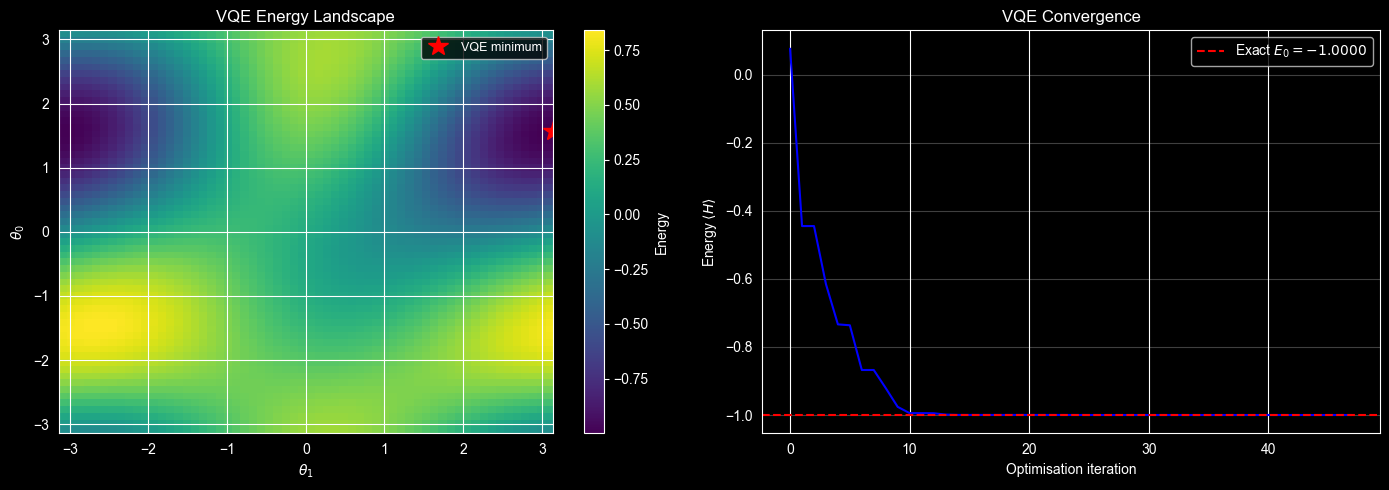

Landscape energy range: [-0.9997, 0.8398]
Convergence: 48 iterations
VQE landscape visualised ✅


In [10]:
# ── VQE landscape and convergence ──

opt_params = result_vqe.x

# ── 2D landscape scan (vary params 0 and 1, fix 2 and 3) ──
theta_range = np.linspace(-np.pi, np.pi, 60)
E_landscape = np.zeros((60, 60))

for i, t0 in enumerate(theta_range):
    for j, t1 in enumerate(theta_range):
        params = [t0, t1, opt_params[2], opt_params[3]]
        E_landscape[i, j] = energy_expectation(params)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Energy landscape
im = ax1.imshow(E_landscape, extent=[-np.pi, np.pi, -np.pi, np.pi],
                origin='lower', cmap='viridis', aspect='auto')
ax1.plot(opt_params[1], opt_params[0], 'r*', markersize=15, label='VQE minimum')
ax1.set_xlabel('$\\theta_1$')
ax1.set_ylabel('$\\theta_0$')
ax1.set_title('VQE Energy Landscape')
ax1.legend(fontsize=9)
fig.colorbar(im, ax=ax1, label='Energy')

# Convergence
ax2.plot(energy_history, 'b-', linewidth=1.5)
ax2.axhline(y=exact_gs_energy, color='r', linestyle='--', label=f'Exact $E_0 = {exact_gs_energy:.4f}$')
ax2.set_xlabel('Optimisation iteration')
ax2.set_ylabel('Energy $\\langle H \\rangle$')
ax2.set_title('VQE Convergence')
ax2.legend()
ax2.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.savefig('vqe_simulation_landscape.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Landscape energy range: [{E_landscape.min():.4f}, {E_landscape.max():.4f}]")
print(f"Convergence: {len(energy_history)} iterations")
print("VQE landscape visualised \u2705")

## Part IX — The Quantum Advantage for Simulation

### Complexity-theoretic argument

Let $H = \sum_{k=1}^{L} H_k$ with $L = O(\text{poly}(n))$ local terms.

| Method | Resources | Scaling in $n$ |
|--------|-----------|----------------|
| Classical exact | $O(2^{2n})$ time | **Exponential** |
| Classical sparse (Krylov) | $O(2^n \cdot \text{poly}(n))$ | **Exponential** (memory-bound) |
| Quantum (1st-order Trotter) | $O(L^2 t^2 / \varepsilon)$ gates | **Polynomial** |
| Quantum (2nd-order Suzuki) | $O(L^{5/2} t^{5/2} / \varepsilon^{1/2})$ gates | **Polynomial** |
| Quantum (qDRIFT, LCU, QSP) | $O(L \cdot t \cdot \text{polylog}(1/\varepsilon))$ | **Polynomial** (near-optimal) |

### BQP-completeness of Hamiltonian simulation

The problem of simulating local Hamiltonian evolution is **BQP-complete** —
it is both *in* BQP (quantum computers can solve it efficiently) and *hard for*
BQP (any efficient quantum computation can be recast as a simulation problem).

**This means:** Hamiltonian simulation is the *natural* problem for quantum computers.
It is simultaneously:
- Exponentially hard for classical computers (unless BPP = BQP, which is widely disbelieved)
- Efficiently solvable on quantum hardware

### The full chain of reasoning

$$\boxed{\text{Qubits} \;=\; \text{Hilbert space}} \;\xrightarrow{\text{Trotter}} \;
\boxed{e^{-iHt} \;\approx\; \text{poly gates}} \;\xrightarrow{\text{JW/BK}} \;
\boxed{\text{Fermions} \;\to\; \text{qubits}} \;\xrightarrow{\text{VQE}} \;
\boxed{\text{NISQ-ready}}$$

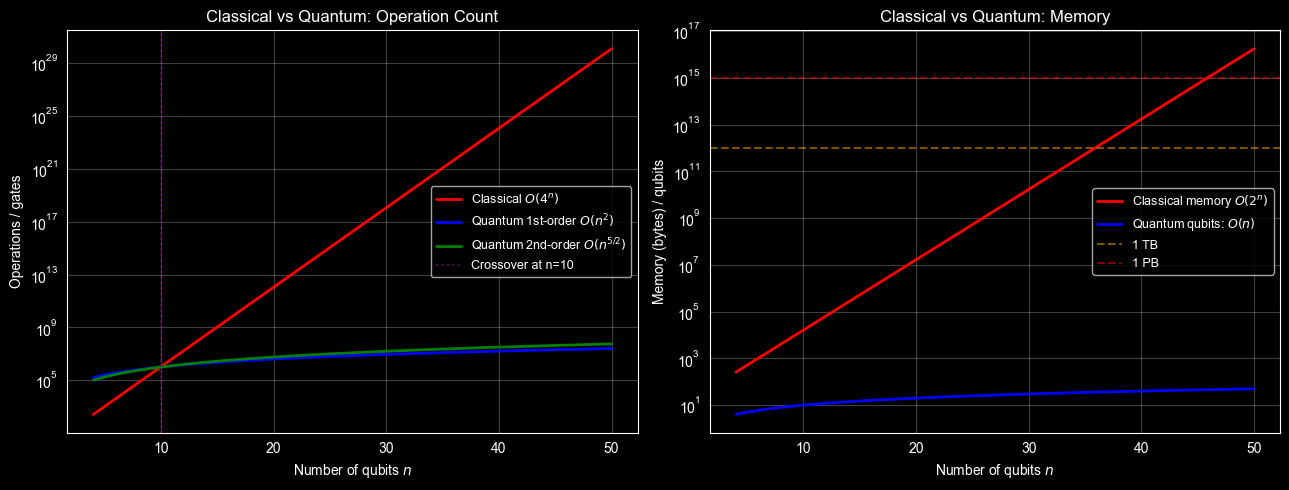

At n=30: classical/quantum ratio = 1.28e+11
Exponential quantum advantage confirmed ✅


In [11]:
# ── Scaling comparison: classical vs quantum resources ──

n_qubits_range = np.arange(4, 51)
L = n_qubits_range  # number of local terms ~ O(n) for nearest-neighbour

# Classical: exact diagonalisation
classical_time = 4.0 ** n_qubits_range  # O(2^{2n})
classical_memory = 2.0 ** n_qubits_range * 16  # bytes

# Quantum: first-order Trotter (gates ~ L^2 t^2 / epsilon)
t_sim_scale = 10.0
epsilon = 0.01
quantum_gates_t1 = L**2 * t_sim_scale**2 / epsilon  # first-order
quantum_gates_t2 = L**2.5 * t_sim_scale**2.5 / np.sqrt(epsilon)  # second-order

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Operations count
ax1.semilogy(n_qubits_range, classical_time, 'r-', linewidth=2, label='Classical $O(4^n)$')
ax1.semilogy(n_qubits_range, quantum_gates_t1, 'b-', linewidth=2, label='Quantum 1st-order $O(n^2)$')
ax1.semilogy(n_qubits_range, quantum_gates_t2, 'g-', linewidth=2, label='Quantum 2nd-order $O(n^{5/2})$')
ax1.set_xlabel('Number of qubits $n$')
ax1.set_ylabel('Operations / gates')
ax1.set_title('Classical vs Quantum: Operation Count')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25, which='both')

# Crossover point
crossover_idx = np.where(classical_time > quantum_gates_t1)[0]
if len(crossover_idx) > 0:
    ax1.axvline(x=n_qubits_range[crossover_idx[0]], color='purple', linestyle=':', alpha=0.7,
                label=f'Crossover at n={n_qubits_range[crossover_idx[0]]}')
    ax1.legend(fontsize=9)

# Memory comparison
ax2.semilogy(n_qubits_range, classical_memory, 'r-', linewidth=2, label='Classical memory $O(2^n)$')
ax2.semilogy(n_qubits_range, n_qubits_range * 1.0, 'b-', linewidth=2, label='Quantum qubits: $O(n)$')
ax2.axhline(y=1e12, color='orange', linestyle='--', alpha=0.5, label='1 TB')
ax2.axhline(y=1e15, color='red', linestyle='--', alpha=0.5, label='1 PB')
ax2.set_xlabel('Number of qubits $n$')
ax2.set_ylabel('Memory (bytes) / qubits')
ax2.set_title('Classical vs Quantum: Memory')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, which='both')

plt.tight_layout()
plt.savefig('quantum_advantage_scaling.png', dpi=120, bbox_inches='tight')
plt.show()

# Verify exponential gap
ratio_30 = classical_time[30-4] / quantum_gates_t1[30-4]
print(f"At n=30: classical/quantum ratio = {ratio_30:.2e}")
assert ratio_30 > 1e10, "Quantum advantage must be enormous at n=30"
print("Exponential quantum advantage confirmed \u2705")

## Takeaways

| Concept | Key Insight |
|---------|-------------|
| **Exponential wall** | Classically simulating $n$ qubits requires $O(2^n)$ memory — intractable beyond $\sim 50$ qubits |
| **Feynman's insight** | Quantum systems should be simulated by quantum hardware that shares the same Hilbert space |
| **Lloyd's theorem** | Any local Hamiltonian $H = \sum H_k$ can be simulated in $\text{poly}(n, t, 1/\varepsilon)$ quantum gates |
| **Trotter-Suzuki** | $e^{-i(A+B)t} \approx (e^{-iA\Delta t}e^{-iB\Delta t})^r$ with controlled, convergent error |
| **Gate decomposition** | $e^{-i\theta ZZ}$, $e^{-i\theta XX}$, $e^{-i\theta YY}$ have exact 2-qubit gate circuits |
| **Jordan-Wigner** | Maps fermionic operators to Pauli strings: $c_j^\dagger = (\prod_{k<j}Z_k)\tfrac{X_j - iY_j}{2}$ |
| **VQE** | Variational hybrid algorithm for NISQ ground-state estimation: $E_0 \leq \min_\theta \langle\psi(\theta)|H|\psi(\theta)\rangle$ |
| **BQP-completeness** | Hamiltonian simulation is the *natural* hard problem for quantum computers — exponentially faster than classical |
| **Quantum advantage** | Classical $O(4^n)$ vs quantum $O(\text{poly}(n))$ — an exponential separation for generic quantum simulation |

> **Next:** `401_quantum_simulation_biology.ipynb` — applying these tools to biological quantum systems,
> and `402_quantum_simulation_chemistry.ipynb` — molecular simulation with VQE and Jordan-Wigner.

---

> **Related notebooks:**
> - `102_quantum_unitary.ipynb` — unitary evolution $U = e^{-iHt}$ fundamentals
> - `200_quantum_hamiltonian.ipynb` — Hamiltonians, Pauli algebra, Ising model
> - `201_quantum_qaoa.ipynb` — variational quantum optimisation (QAOA)
> - `300_quantum_majorana.ipynb` — topological simulation of Kitaev chain
> - `401_` / `402_` — biological and chemical quantum simulation (upcoming)